In [84]:
import pandas as pd

df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.tail())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83


In [85]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


# Does not contain Missing Value
If Missing values did exist we can use the following:

df = df.fillna(df.mean(numeric_only=True)) *for replacing missing values with the numeric mean*
                            **or**
df = df.dropna() *for dropping missing values*

In [86]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Gender'].head()


0    1
1    1
2    0
3    0
4    0
Name: Gender, dtype: int64

In [87]:
import numpy as np

# Drop CustomerID (not useful)
df = df.drop('CustomerID', axis=1)

# Convert to NumPy array
data = df.values

# Z-score normalization
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)

normalized_data = (data - mean) / std

# Convert back to DataFrame
df_norm = pd.DataFrame(normalized_data, columns=df.columns)

print(df_norm.head())


     Gender       Age  Annual Income (k$)  Spending Score (1-100)
0  1.128152 -1.424569           -1.738999               -0.434801
1  1.128152 -1.281035           -1.738999                1.195704
2 -0.886405 -1.352802           -1.700830               -1.715913
3 -0.886405 -1.137502           -1.700830                1.040418
4 -0.886405 -0.563369           -1.662660               -0.395980


# PART B


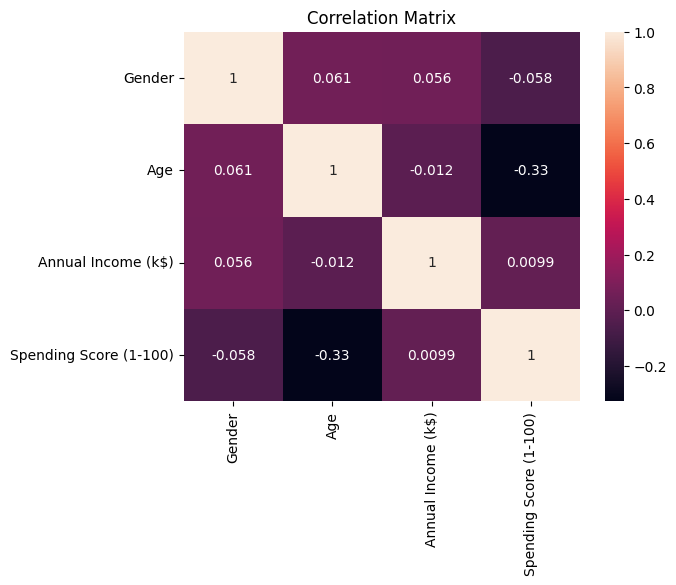

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_norm.corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

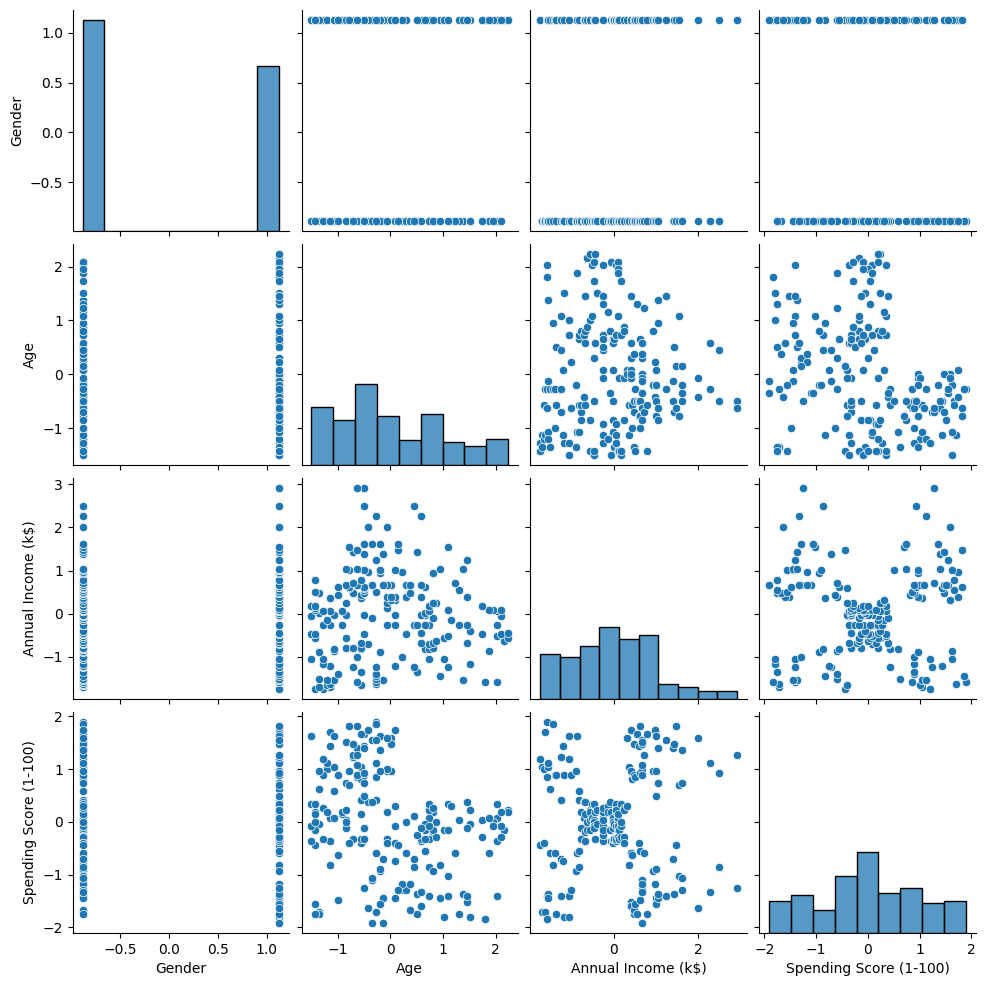

In [89]:
sns.pairplot(df_norm)
plt.show()

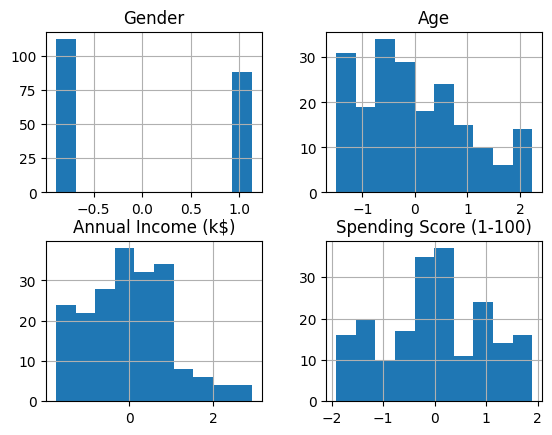

In [90]:
df_norm.hist()
plt.show()

# PART C

In [114]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_norm)

df_norm['Cluster'] = clusters
print(df_norm['Cluster'].head())

0    2
1    2
2    2
3    2
4    2
Name: Cluster, dtype: int32


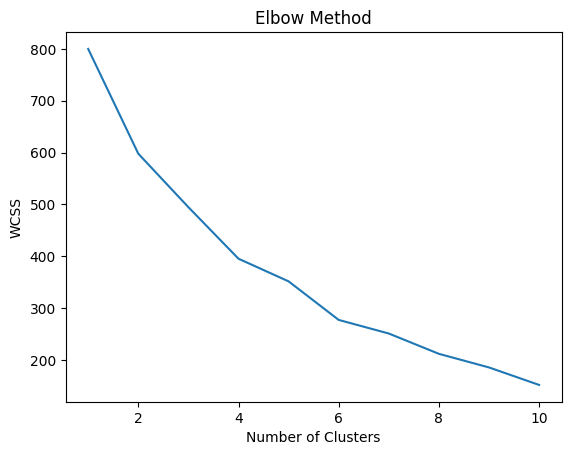

In [115]:
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(df_norm.drop('Cluster', axis=1))
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [116]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df_norm.drop('Cluster', axis=1), clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.19528247398631643


# PART D

In [117]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_norm.drop('Cluster', axis=1))
print(pca_data[:5])

[[-0.40638272 -0.52071363]
 [-1.42767287 -0.3673102 ]
 [ 0.05076057 -1.89406774]
 [-1.6945131  -1.63190805]
 [-0.31310838 -1.81048272]]


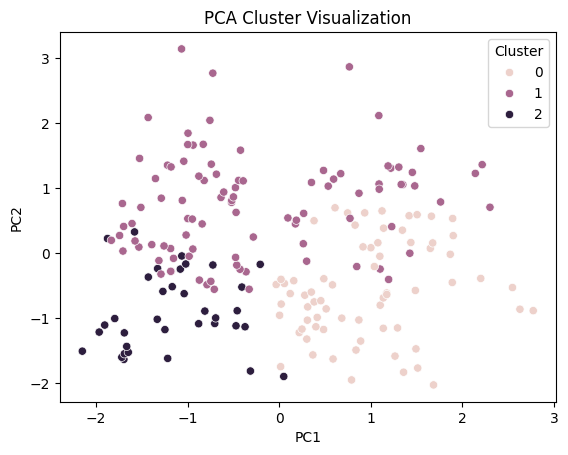

In [118]:
pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['Cluster'] = clusters

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df)
plt.title("PCA Cluster Visualization")
plt.show()

In [113]:
print(df.groupby(clusters).mean())

     Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  1.000000  56.535714           46.178571               40.035714
1  0.000000  50.487805           48.487805               39.585366
2  0.000000  26.240000           33.120000               64.040000
3  0.606061  40.787879           88.909091               17.121212
4  1.000000  24.136364           41.454545               62.681818
5  0.000000  29.848485           78.454545               68.575758
6  1.000000  33.277778           87.111111               82.666667


In [107]:
print("Insights:")
print("Cluster 0: Average customers")
print("Cluster 1: High-value customers")
print("Cluster 2: Low-value customers")

print("\nRecommendations:")
print("- Focus marketing on high-value customers")
print("- Provide discounts to low-value customers")
print("- Engage average customers for growth")

Insights:
Cluster 0: Average customers
Cluster 1: High-value customers
Cluster 2: Low-value customers

Recommendations:
- Focus marketing on high-value customers
- Provide discounts to low-value customers
- Engage average customers for growth
